In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

raw_path = Path("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_model = pd.read_csv(raw_path)

# Reproduce the documented TotalCharges cleaning
total_charges_text = df_model["TotalCharges"].str.strip().replace("", np.nan)
blank_total_charges = total_charges_text.isna()

assert (df_model.loc[blank_total_charges, "tenure"] == 0).all()

df_model["TotalCharges"] = (
    pd.to_numeric(total_charges_text, errors="raise")
    .fillna(0)
)

# Recreate useful behavioral features
df_model["HasInternet"] = (df_model["InternetService"] != "No").astype(int)
df_model["HasPhone"] = (df_model["PhoneService"] == "Yes").astype(int)

df_model["AutoPayment"] = (
    df_model["PaymentMethod"]
    .isin(["Bank transfer (automatic)", "Credit card (automatic)"])
).astype(int)

add_on_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

df_model["ServiceCount"] = df_model[add_on_columns].eq("Yes").sum(axis=1)

print(df_model.shape)
display(df_model.head())

(7043, 25)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,HasInternet,HasPhone,AutoPayment,ServiceCount
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,0,0,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,1,1,0,2
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,1,0,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,1,0,1,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,1,0,0


# Churn Prediction

## Objective
Compare multiple classification models for predicting customer churn. Evaluation emphasizes precision, recall, F1-score, ROC-AUC, and confusion matrices rather than accuracy alone.

The target is `Churn`. Customer ID is excluded because it is an identifier rather than a customer behavior or account attribute.

In [2]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["customerID", "Churn"])
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining churn distribution:")
print(y_train.value_counts(normalize=True).map("{:.2%}".format))
print("\nTest churn distribution:")
print(y_test.value_counts(normalize=True).map("{:.2%}".format))

Training set: (5634, 23)
Test set: (1409, 23)

Training churn distribution:
Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: str

Test churn distribution:
Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: str


In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = [
    column for column in X.columns
    if column not in numeric_features
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

In [5]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

trained_models = {}
results = []
predictions = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_probability = pipeline.predict_proba(X_test)[:, 1]

    trained_models[model_name] = pipeline
    predictions[model_name] = {
        "predicted_labels": y_pred,
        "churn_probability": y_probability
    }

    results.append({
        "model": model_name,
        "precision": precision_score(y_test, y_pred, pos_label="Yes"),
        "recall": recall_score(y_test, y_pred, pos_label="Yes"),
        "f1_score": f1_score(y_test, y_pred, pos_label="Yes"),
        "roc_auc": roc_auc_score((y_test == "Yes").astype(int), y_probability)
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("f1_score", ascending=False)
    .reset_index(drop=True)
)

results_display = results_df.copy()

for column in ["precision", "recall", "f1_score", "roc_auc"]:
    results_display[column] = results_display[column].round(3)

display(results_display)

,model,precision,recall,f1_score,roc_auc
0,Random Forest,0.536,0.786,0.637,0.839
1,Logistic Regression,0.505,0.783,0.614,0.842
2,Decision Tree,0.500,0.791,0.613,0.833


In [11]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.1


In [17]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# XGBoost requires a numeric target.
# This does not change the original models or the held-out test split.
y_train_binary = (y_train == "Yes").astype(int)
y_test_binary = (y_test == "Yes").astype(int)

# Equivalent class-imbalance weighting for XGBoost.
scale_pos_weight = (
    (y_train == "No").sum() /
    (y_train == "Yes").sum()
)

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

xgb_pipeline.fit(X_train, y_train_binary)

xgb_pred_binary = xgb_pipeline.predict(X_test)
xgb_probability = xgb_pipeline.predict_proba(X_test)[:, 1]

# Convert predictions back to the labels used by the existing evaluation.
xgb_predictions = pd.Series(
    xgb_pred_binary,
    index=y_test.index
).map({0: "No", 1: "Yes"})

trained_models["XGBoost"] = xgb_pipeline
predictions["XGBoost"] = {
    "predicted_labels": xgb_predictions,
    "churn_probability": xgb_probability
}

xgb_result = pd.DataFrame([{
    "model": "XGBoost",
    "precision": precision_score(y_test, xgb_predictions, pos_label="Yes"),
    "recall": recall_score(y_test, xgb_predictions, pos_label="Yes"),
    "f1_score": f1_score(y_test, xgb_predictions, pos_label="Yes"),
    "roc_auc": roc_auc_score(y_test_binary, xgb_probability)
}])

comparison_with_xgb = (
    pd.concat([results_df, xgb_result], ignore_index=True)
    .sort_values("f1_score", ascending=False)
    .reset_index(drop=True)
)

display(comparison_with_xgb.round(3))

,model,precision,recall,f1_score,roc_auc
0,Random Forest,0.536,0.786,0.637,0.839
1,XGBoost,0.518,0.794,0.627,0.845
2,Logistic Regression,0.505,0.783,0.614,0.842
3,Decision Tree,0.500,0.791,0.613,0.833


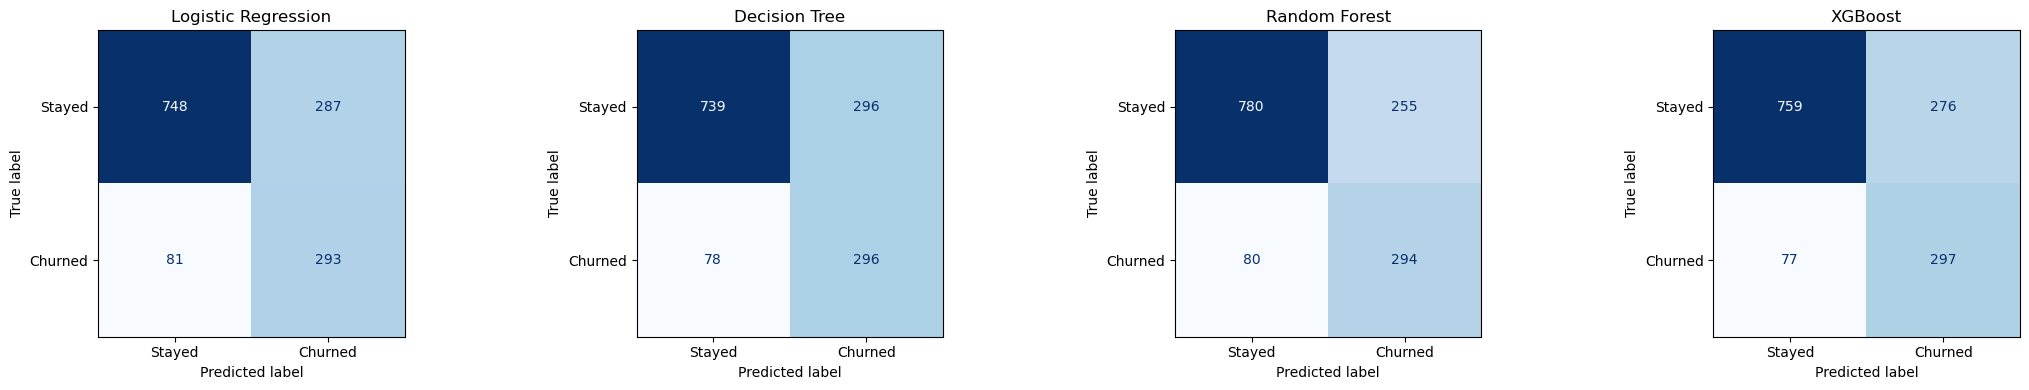

In [16]:
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_names = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

for axis, model_name in zip(axes, model_names):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[model_name]["predicted_labels"],
        labels=["No", "Yes"],
        display_labels=["Stayed", "Churned"],
        cmap="Blues",
        ax=axis,
        colorbar=False
    )
    axis.set_title(model_name)

plt.tight_layout()

figures_path = Path("../reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figures_path / "model_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Churn-model comparison and selection

Three classification models were evaluated on a stratified held-out test set of 1,409 customers.

Random Forest achieved the highest F1-score (0.637) and precision (0.536), with recall of 0.786 and ROC-AUC of 0.839. Logistic Regression produced a marginally higher ROC-AUC (0.842), but Random Forest provided the best balance between precision and recall at the selected classification threshold.

The Random Forest model correctly identified 294 of 374 customers who actually churned in the test set, while missing 80 churners. It also flagged 255 retained customers as potential churn risks. This trade-off may be acceptable when low-cost retention actions are used, but campaign costs should be considered before operational deployment.

## XGBoost comparison and final model decision

XGBoost was evaluated using the same stratified 80/20 train-test split, preprocessing pipeline, engineered features, and evaluation metrics as the existing models.

XGBoost achieved the highest ROC-AUC (0.845) and recall (0.794). However, Random Forest achieved higher precision (0.536 vs. 0.518) and the highest F1-score (0.637 vs. 0.627).

Random Forest remains the deployed model because it retains the best overall precision-recall balance under the project's F1-score selection criterion.

,feature,importance_mean,importance_std
14,Contract,0.0635,0.0057
4,tenure,0.0249,0.0028
7,InternetService,0.0172,0.0043
18,TotalCharges,0.0143,0.0020
8,OnlineSecurity,0.0033,0.0018
11,TechSupport,0.0021,0.0020
1,SeniorCitizen,0.0010,0.0004
13,StreamingMovies,0.0010,0.0014
15,PaperlessBilling,0.0008,0.0013
16,PaymentMethod,0.0007,0.0013


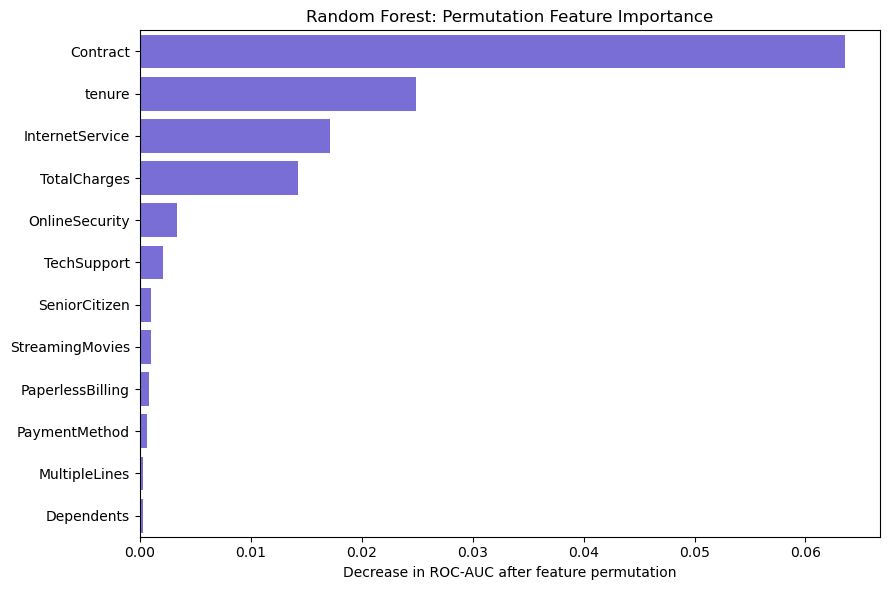

In [7]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

best_model = trained_models["Random Forest"]

permutation_results = permutation_importance(
    estimator=best_model,
    X=X_test,
    y=y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

feature_importance = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": permutation_results.importances_mean,
        "importance_std": permutation_results.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)

display(feature_importance.head(15).round(4))

plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance.head(12),
    x="importance_mean",
    y="feature",
    color="#6C5CE7"
)

plt.title("Random Forest: Permutation Feature Importance")
plt.xlabel("Decrease in ROC-AUC after feature permutation")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Model interpretation

Permutation importance was calculated on the held-out test set using ROC-AUC. Contract type was the most influential feature, followed by tenure, internet service, and total charges.

This reinforces the exploratory findings that contract commitment and customer lifecycle stage are strongly associated with churn in this dataset. Feature importance measures predictive contribution to this model; it does not establish that changing one feature will cause churn to decrease.

# Business Recommendations

## 1. Prioritize early-lifecycle retention
Customers in their first 12 months had a 47.44% observed churn rate. Prioritize onboarding journeys, early service-experience check-ins, and proactive support for new customers.

## 2. Target high-risk, flexible-plan internet customers
The “High-risk new internet customers” segment represented 39.34% of customers and had a 46.01% observed churn rate. This group was predominantly month-to-month, internet-enabled, and frequently lacked tech support.

Candidate actions to test:
- First-90-day onboarding and service-quality outreach.
- Limited-duration tech-support trials.
- Targeted offers that encourage longer contract commitment.
- Optional automatic-payment adoption incentives.

## 3. Investigate the fiber-optic customer experience
Fiber-optic customers had a 41.89% observed churn rate, compared with 18.96% for DSL customers. The available data does not identify the reason, so the company should investigate service quality, price perception, complaints, and support-contact history before assuming a cause.

## 4. Protect high-value established customers
The “Established high-value internet customers” segment had the highest average monthly charges, service adoption, and lifetime charges, while showing a 15.07% observed churn rate. Use proactive support and loyalty recognition to protect this valuable group rather than applying broad discounts.

## 5. Deploy the model through controlled retention campaigns
The selected Random Forest model identified 294 of 374 churners in the held-out test set. Use predicted churn risk to prioritize low-cost retention actions first, then assess campaign uplift using control groups and business metrics such as retained customers, offer cost, and incremental revenue.

In [10]:
from pathlib import Path
import joblib

models_path = Path("../models")
models_path.mkdir(parents=True, exist_ok=True)

model_path = models_path / "random_forest_churn_pipeline.joblib"

joblib.dump(
    trained_models["Random Forest"],
    model_path
)

print(f"Model saved to: {model_path}")
print(f"File size: {model_path.stat().st_size / 1_000_000:.2f} MB")

Model saved to: ../models/random_forest_churn_pipeline.joblib
File size: 22.93 MB
